In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [307]:
bon = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/bonneville.csv")
tda = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/dalles.csv")
jda = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/johnday.csv")
mcn = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/mcnary.csv")

In [5]:
bonsoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/bonneville-soc.csv")
tdasoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/dalles-soc.csv")
jdasoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/johnday-soc.csv")
mcnsoc = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/mcnary-soc.csv")

In [6]:
bon.rename(columns={"BON.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "BON.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "BON.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
tda.rename(columns={"TDA.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "TDA.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "TDA.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
jda.rename(columns={"JDA.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "JDA.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "JDA.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
mcn.rename(columns={"MCN.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "MCN.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "MCN.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)

In [7]:
bonsoc.rename(columns={"BON.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)
tdasoc.rename(columns={"TDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)
jdasoc.rename(columns={"JDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)
mcnsoc.rename(columns={"MCN.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]": "soc_ft"}, inplace=True)

In [8]:
soc_df = (
    bonsoc[["Date Time", "soc_ft"]]
    .rename(columns={"soc_ft": "bon_soc_ft"})
    .merge(
        tdasoc[["Date Time", "soc_ft"]]
        .rename(columns={"soc_ft": "tda_soc_ft"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        jdasoc[["Date Time", "soc_ft"]]
        .rename(columns={"soc_ft": "jda_soc_ft"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        mcnsoc[["Date Time", "soc_ft"]]
        .rename(columns={"soc_ft": "mcn_soc_ft"}),
        on="Date Time",
        how="inner",
    )
)

In [9]:
bon = bon.bfill()
tda = tda.bfill()
jda = jda.bfill()
mcn = mcn.bfill()

In [10]:
dfs = {
    "bon": bon,
    "tda": tda,
    "jda": jda,
    "mcn": mcn,
}

## System Parameters

In [12]:
def flow_limits(dfs, flow_col="outflow (kcfs)"):
    rows = []
    for name, df in dfs.items():
        x = df[flow_col].dropna()
        ramp = x.diff().dropna()
        rows.append({"unit": name, "min_flow_kcfs": x.min(), "max_flow_kcfs": x.max(), "min_ramp_kcfs_per_hr": ramp.min(), "max_ramp_kcfs_per_hr": ramp.max()})
    return pd.DataFrame(rows)

In [13]:
dfs = {"bon": bon, "tda": tda, "jda": jda, "mcn": mcn}
limits = flow_limits(dfs, flow_col="outflow (kcfs)")
print(limits)

  unit  min_flow_kcfs  max_flow_kcfs  min_ramp_kcfs_per_hr  \
0  bon           29.0          260.0                -120.6   
1  tda           23.4          268.3                -118.1   
2  jda           47.5          265.4                -133.7   
3  mcn            0.0          230.8                 -94.6   

   max_ramp_kcfs_per_hr  
0                  68.7  
1                 110.2  
2                 135.0  
3                  94.6  


## Hydrograph

In [15]:
flow_dfs = [
    df[["Date Time", "inflow (kcfs)"]]
      .rename(columns={"inflow (kcfs)": f"{name}_inflow_kcfs"})
    for name, df in dfs.items()
]

hydrograph_df = (
    bon[["Date Time", "inflow (kcfs)"]]
    .rename(columns={"inflow (kcfs)": "bon_inflow_kcfs"})
    .merge(
        tda[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "tda_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        jda[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "jda_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        mcn[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "mcn_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
)

In [16]:
inflow_cols = [
    "bon_inflow_kcfs",
    "tda_inflow_kcfs",
    "jda_inflow_kcfs",
    "mcn_inflow_kcfs",
]

kcfs_to_m3s = 28.316846592

hydrograph_df["mean_inflow_m3s"] = hydrograph_df[inflow_cols].mean(axis=1) * kcfs_to_m3s

hydrograph_df["Date Time"] = pd.to_datetime(hydrograph_df["Date Time"])

hydrograph_df = hydrograph_df[hydrograph_df["Date Time"] >= "2018-01-01"].copy()

In [17]:
hydrograph_df.head()

,Date Time,bon_inflow_kcfs,tda_inflow_kcfs,jda_inflow_kcfs,mcn_inflow_kcfs,mean_inflow_m3s
4,2018-01-01 00:00:00,184.574,179.31,176.265,171.521,5038.062554
5,2018-01-01 01:00:00,184.574,179.31,176.265,171.521,5038.062554
6,2018-01-01 02:00:00,184.574,179.31,176.265,171.521,5038.062554
7,2018-01-01 03:00:00,184.574,179.31,176.265,171.521,5038.062554
8,2018-01-01 04:00:00,184.574,179.31,176.265,171.521,5038.062554


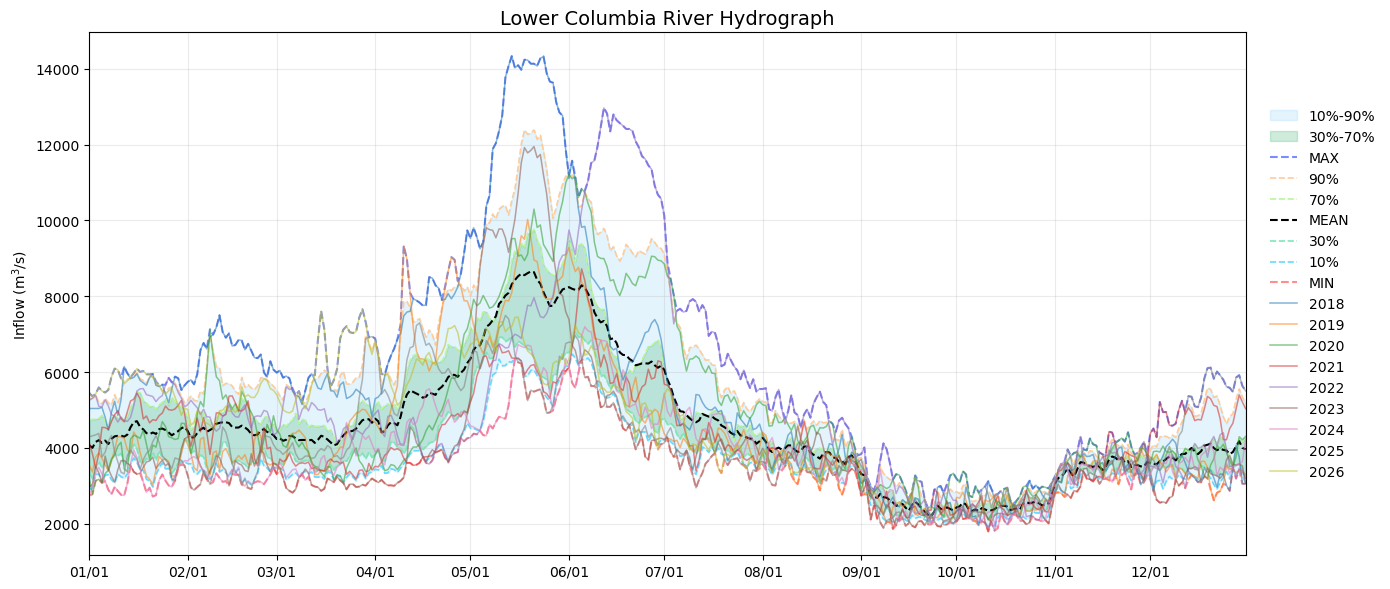

In [18]:
import matplotlib.dates as mdates

plot_individual_years = True # Toggle: True = show yearly lines, False = hide them

df = hydrograph_df.copy()

df["Date Time"] = pd.to_datetime(df["Date Time"])
df = df[df["Date Time"] >= "2018-01-01"].copy()

df["year"] = df["Date Time"].dt.year
df["month"] = df["Date Time"].dt.month
df["day"] = df["Date Time"].dt.day

# Remove leap day so every year maps cleanly onto Jan 1-Dec 31
df = df[~((df["month"] == 2) & (df["day"] == 29))].copy()

# Use a common non-leap year for plotting all years on the same Jan-Dec axis
df["plot_date"] = pd.to_datetime(
    {
        "year": 2023,
        "month": df["month"],
        "day": df["day"],
    }
)

df = df.dropna(subset=["plot_date", "mean_inflow_m3s"])

# Daily average in case your data are hourly/subdaily
daily = (
    df.groupby(["year", "plot_date"], as_index=False)["mean_inflow_m3s"]
    .mean()
)

stats = (
    daily.groupby("plot_date")["mean_inflow_m3s"]
    .agg(
        min_flow="min",
        mean_flow="mean",
        max_flow="max",
        q10=lambda x: x.quantile(0.10),
        q30=lambda x: x.quantile(0.30),
        q70=lambda x: x.quantile(0.70),
        q90=lambda x: x.quantile(0.90),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

# Shaded quantile bands
ax.fill_between(
    stats["plot_date"],
    stats["q10"],
    stats["q90"],
    color="lightskyblue",
    alpha=0.22,
    label="10%-90%",
)

ax.fill_between(
    stats["plot_date"],
    stats["q30"],
    stats["q70"],
    color="mediumseagreen",
    alpha=0.25,
    label="30%-70%",
)

# Summary statistics
ax.plot(stats["plot_date"], stats["max_flow"], color="#7b8cff", linestyle="--", linewidth=1.5, label="MAX")
ax.plot(stats["plot_date"], stats["q90"], color="#ffcc99", linestyle="--", linewidth=1.2, label="90%")
ax.plot(stats["plot_date"], stats["q70"], color="#b9f59b", linestyle="--", linewidth=1.2, label="70%")
ax.plot(stats["plot_date"], stats["mean_flow"], color="black", linestyle="--", linewidth=1.5, label="MEAN")
ax.plot(stats["plot_date"], stats["q30"], color="#7ee6b8", linestyle="--", linewidth=1.2, label="30%")
ax.plot(stats["plot_date"], stats["q10"], color="#66d9ff", linestyle="--", linewidth=1.2, label="10%")
ax.plot(stats["plot_date"], stats["min_flow"], color="#ff8f8f", linestyle="--", linewidth=1.5, label="MIN")

# Optional individual yearly hydrographs
if plot_individual_years:
    for year, group in daily.groupby("year"):
        ax.plot(
            group["plot_date"],
            group["mean_inflow_m3s"],
            linewidth=1.1,
            alpha=0.55,
            label=str(year),
        )

ax.set_title("Lower Columbia River Hydrograph", fontsize=14)
ax.set_ylabel("Inflow (m$^3$/s)")
ax.set_xlabel("")

ax.set_xlim(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

ax.grid(True, alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.tight_layout()
plt.show()

## Dry Season Analysis

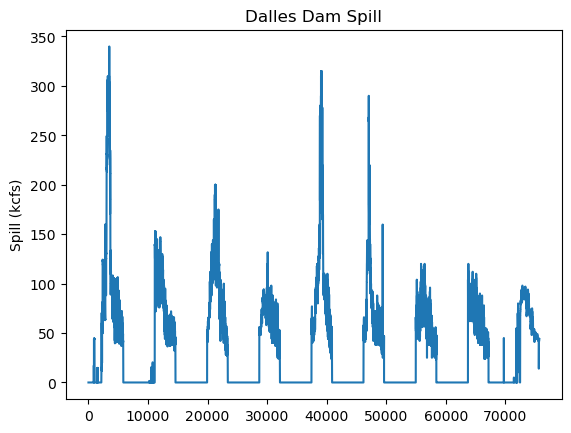

In [20]:
plt.plot(tda["spill (kcfs)"])
plt.title("Dalles Dam Spill")
plt.ylabel("Spill (kcfs)")
plt.show()

In [21]:
df = tda.copy()

df["Date Time"] = pd.to_datetime(df["Date Time"])
df = df.sort_values("Date Time").copy()
df = df[df["Date Time"] >= "2018-01-01"]

spill_col = "spill (kcfs)"  

# Smooth the time series rolling window
window = 14*24  # active window
min_spill_days = 7*24

df["spill_days_rolling"] = (
    df[spill_col]
    .rolling(window=window, center=True, min_periods=1)
    .sum()
)

# Minimum days of spill 
df["spill_active_smooth"] = df["spill_days_rolling"] >= min_spill_days

# Define dry season as smoothed no-spill periods
df["dry_season"] = ~df["spill_active_smooth"]

In [22]:
df.head()

,Date Time,outflow (kcfs),inflow (kcfs),spill (kcfs),spill_days_rolling,spill_active_smooth,dry_season
4,2018-01-01 00:00:00,148.4,179.31,0.0,0.0,False,True
5,2018-01-01 01:00:00,123.9,179.31,0.0,0.0,False,True
6,2018-01-01 02:00:00,121.1,179.31,0.0,0.0,False,True
7,2018-01-01 03:00:00,121.9,179.31,0.0,0.0,False,True
8,2018-01-01 04:00:00,121.6,179.31,0.0,0.0,False,True


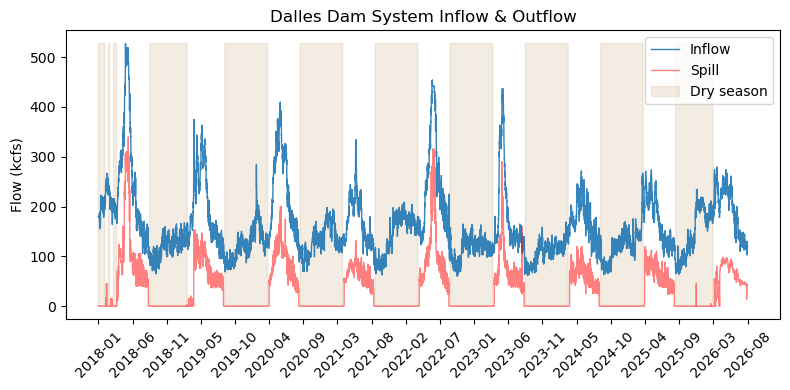

In [23]:
plt.figure(figsize=(8, 4))

tick_idx = np.linspace(0, len(df)-1, 20).astype(int)
#plt.plot(df["Date Time"], df["outflow (kcfs)"], linewidth=1, label="Gen. Outflow", color="green", alpha = 0.5)
plt.plot(df["Date Time"], df["inflow (kcfs)"], linewidth=1, label="Inflow", alpha = 0.9)
plt.plot(df["Date Time"], df[spill_col], linewidth=1, label="Spill", color = "red", alpha = 0.5)

plt.fill_between(df["Date Time"], 0, df["inflow (kcfs)"].max(), where=df["dry_season"], color="tan", alpha=0.25, label="Dry season")
plt.xticks(df["Date Time"].iloc[tick_idx], df["Date Time"].iloc[tick_idx].dt.strftime("%Y-%m"), rotation=45)

plt.ylabel("Flow (kcfs)")
plt.title("Dalles Dam System Inflow & Outflow")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
dry_blocks = df[df["dry_season"]].copy()
dry_blocks["block"] = (dry_blocks["Date Time"].diff() > pd.Timedelta(hours=1)).cumsum()
dry_ranges = dry_blocks.groupby("block")["Date Time"].agg(["min", "max"])
dry_ranges["days"] = (dry_ranges["max"] - dry_ranges["min"]).dt.days
dry_ranges = dry_ranges[dry_ranges["days"] >= 40]

print("Dry season training date ranges:")
for _, row in dry_ranges.iterrows(): print(f"{row['min'].strftime('%Y-%m-%d')} to {row['max'].strftime('%Y-%m-%d')}")

Dry season training date ranges:
2018-09-07 to 2018-11-26
2018-11-26 to 2019-03-08
2019-09-07 to 2020-04-03
2020-09-07 to 2021-04-03
2021-09-07 to 2022-04-03
2022-09-07 to 2022-11-09
2022-11-10 to 2023-04-03
2023-10-17 to 2024-03-18
2024-09-07 to 2025-04-03
2025-09-07 to 2026-03-08


### Rank Driest Year

In [26]:
flow_col = "mean_inflow_m3s"
df_flow = hydrograph_df.copy()
df_flow["Date Time"] = pd.to_datetime(df_flow["Date Time"])
dry_90_flow = df_flow[((df_flow["Date Time"].dt.month == 9) & (df_flow["Date Time"].dt.day >= 7)) | (df_flow["Date Time"].dt.month.isin([10, 11])) | ((df_flow["Date Time"].dt.month == 12) & (df_flow["Date Time"].dt.day <= 5))].copy()
dry_90_flow["dry_year"] = dry_90_flow["Date Time"].dt.year
dry_rank = dry_90_flow.groupby("dry_year")[flow_col].agg(["mean", "min", "max"]).sort_values("mean")
print(dry_rank)

                 mean          min          max
dry_year                                       
2023      2620.814712  1714.839913  4382.053248
2024      2721.669141  1751.984536  3851.954800
2019      2821.764159  1931.669086  4220.222469
2025      2856.971135  1774.149548  4309.710784
2021      2886.486209  1739.234876  5549.910793
2022      2917.205257  1680.116380  4584.476226
2018      2934.280913  1812.731251  4429.682184
2020      3208.168699  1928.681659  4896.180994


### Export Data

In [28]:
save_df = hydrograph_df[((hydrograph_df["Date Time"].dt.month == 9) & (hydrograph_df["Date Time"].dt.day >= 7)) | (hydrograph_df["Date Time"].dt.month.isin([10, 11])) | ((hydrograph_df["Date Time"].dt.month == 12) & (hydrograph_df["Date Time"].dt.day <= 5))].copy()
save_df = save_df.drop(columns="mean_inflow_m3s") 

In [29]:
## Min Max Normalize data based on dry season flow min and max 
inflow_cols = [
    "bon_inflow_kcfs",
    "tda_inflow_kcfs",
    "jda_inflow_kcfs",
    "mcn_inflow_kcfs"
]

q_min = save_df[inflow_cols].min().min()
q_max = save_df[inflow_cols].max().max()

inflow_data_norm = save_df.copy()
# inflow_data_norm[inflow_cols] = (save_df[inflow_cols] - q_min) / (q_max - q_min)

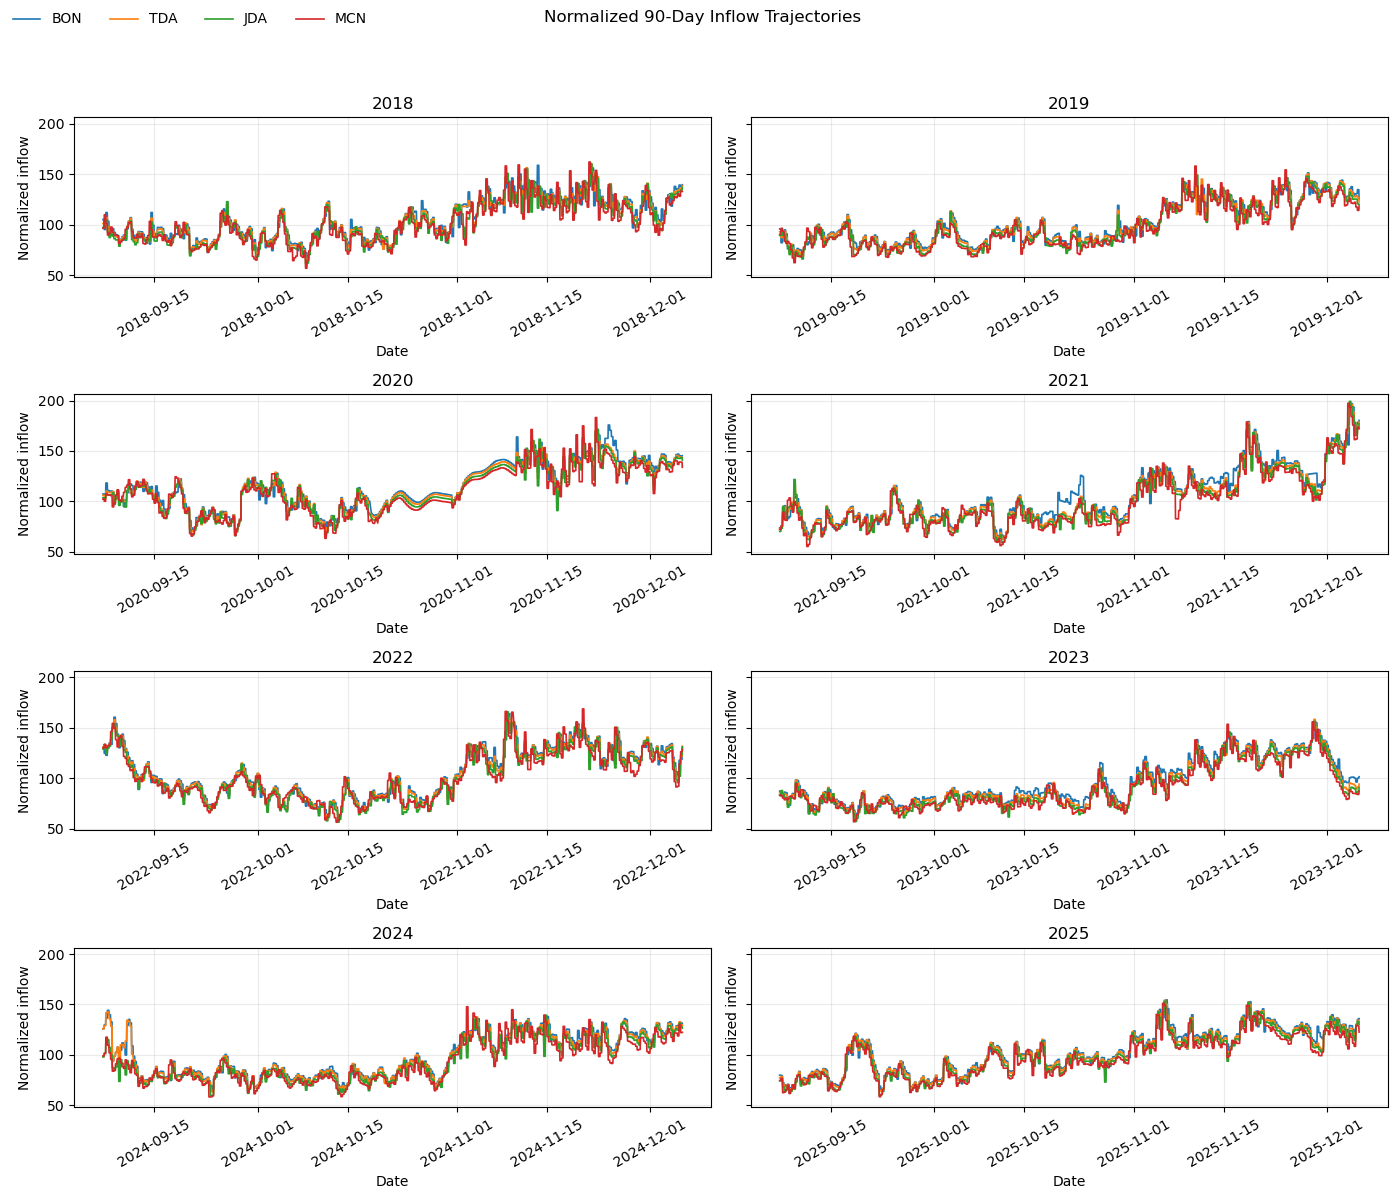

In [30]:
# Remove "_kcfs" from column names
inflow_data_norm = inflow_data_norm.rename(
    columns=lambda col: col.replace("_kcfs", "")
)

# Ensure Date Time is datetime
inflow_data_norm["Date Time"] = pd.to_datetime(
    inflow_data_norm["Date Time"]
)

inflow_cols = [
    "bon_inflow",
    "tda_inflow",
    "jda_inflow",
    "mcn_inflow"
]

years = sorted(inflow_data_norm["Date Time"].dt.year.unique())

fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 12),
    sharey=True
)

axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = inflow_data_norm[
        inflow_data_norm["Date Time"].dt.year == year
    ]

    for col in inflow_cols:
        ax.plot(
            df_year["Date Time"],
            df_year[col],
            label=col.replace("_inflow", "").upper(),
            linewidth=1.2
        )

    ax.set_title(str(year))
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized inflow")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

# Use one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=4,
    frameon=False
)

fig.suptitle("Normalized 90-Day Inflow Trajectories", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [31]:
inflow_data_norm = inflow_data_norm.rename(columns={"Date Time": "datetime"}) 

### Find Missing Dates and Interpolate 

In [33]:
len(inflow_data_norm) # should be 17280 

17224

In [34]:
years = range(2018, 2026)  # Complete seasons: 2018-2025

# Expected hourly timestamps
expected = pd.DatetimeIndex([]).append([pd.date_range(f"{y}-09-07", f"{y}-12-05 23:00", freq="h") for y in years])

In [35]:
expected

DatetimeIndex(['2018-09-07 00:00:00', '2018-09-07 01:00:00',
               '2018-09-07 02:00:00', '2018-09-07 03:00:00',
               '2018-09-07 04:00:00', '2018-09-07 05:00:00',
               '2018-09-07 06:00:00', '2018-09-07 07:00:00',
               '2018-09-07 08:00:00', '2018-09-07 09:00:00',
               ...
               '2025-12-05 14:00:00', '2025-12-05 15:00:00',
               '2025-12-05 16:00:00', '2025-12-05 17:00:00',
               '2025-12-05 18:00:00', '2025-12-05 19:00:00',
               '2025-12-05 20:00:00', '2025-12-05 21:00:00',
               '2025-12-05 22:00:00', '2025-12-05 23:00:00'],
              dtype='datetime64[ns]', length=17280, freq=None)

In [36]:
# Check missing timestamps
missing = expected.difference(inflow_data_norm["datetime"])
print("Missing hours by year:")
print(pd.Series(missing.year).value_counts().sort_index())

Missing hours by year:
2018     3
2019     1
2020    26
2021     4
2022    20
2023     2
Name: count, dtype: int64


In [37]:
# Remove duplicate timestamps and add missing rows
inflow_data_norm = (
    inflow_data_norm.groupby("datetime", as_index=False)[inflow_cols]
    .mean()
    .set_index("datetime")
    .reindex(expected)
)

In [38]:
print(inflow_data_norm.shape)     
print(inflow_data_norm.isna().sum())

(17280, 4)
bon_inflow    56
tda_inflow    56
jda_inflow    56
mcn_inflow    56
dtype: int64


In [39]:
# Interpolate data
inflow_data_norm[inflow_cols] = inflow_data_norm[inflow_cols].bfill()

inflow_data_norm = inflow_data_norm.reset_index(names="datetime")

print(inflow_data_norm.shape)     
print(inflow_data_norm.isna().sum())

(17280, 5)
datetime      0
bon_inflow    0
tda_inflow    0
jda_inflow    0
mcn_inflow    0
dtype: int64


In [40]:
inflow_data_norm.head()

,datetime,bon_inflow,tda_inflow,jda_inflow,mcn_inflow
0,2018-09-07 00:00:00,105.091,101.074,97.247,96.451
1,2018-09-07 01:00:00,105.091,101.074,97.247,96.451
2,2018-09-07 02:00:00,105.091,101.074,97.247,96.451
3,2018-09-07 03:00:00,105.091,101.074,97.247,96.451
4,2018-09-07 04:00:00,105.091,101.074,97.247,96.451


In [41]:
len(inflow_data_norm)

17280

In [42]:
# not normalized!

inflow_data_norm.to_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/inflow.csv", index=False)

# SOC Reference 

In [44]:
## Merge on 90 Day Datetime Dataset 

soc_df = soc_df.rename(columns={"Date Time": "datetime"})

soc_df["datetime"] = pd.to_datetime(soc_df["datetime"])
inflow_data_norm["datetime"] = pd.to_datetime(inflow_data_norm["datetime"])

soc_df = soc_df.merge(
    inflow_data_norm[["datetime"]],
    on="datetime",
    how="inner"
)

In [45]:
# Min - Max normalization each column uniquely 
soc_cols = ["bon_soc_ft", "tda_soc_ft", "jda_soc_ft", "mcn_soc_ft"]

volume_max = {
    "bon_soc_ft": 1.5,
    "tda_soc_ft": 1.0,
    "jda_soc_ft": 1.5,
    "mcn_soc_ft": 4.0,
}

soc_df_norm = soc_df.copy()
soc_df_norm[soc_cols] = (soc_df_norm[soc_cols] - soc_df_norm[soc_cols].min()) / (soc_df_norm[soc_cols].max() - soc_df_norm[soc_cols].min())

#for col in soc_cols:
#    soc_df_norm[col] *= volume_max[col]

In [46]:
# Remove "_ft" from column names
soc_df_norm = soc_df_norm.rename(
    columns=lambda col: col.replace("_ft", "")
)

In [47]:
# Check missing timestamps
missing = expected.difference(soc_df_norm["datetime"])
print("Missing hours by year:")
print(pd.Series(missing.year).value_counts().sort_index())

Missing hours by year:
2018     4
2019     2
2020    31
2021     4
2022    26
2023     3
Name: count, dtype: int64


In [48]:
# Remove duplicate timestamps and add missing rows
soc_cols = ["bon_soc", "tda_soc", "jda_soc", "mcn_soc"]

soc_df_norm = (
    soc_df_norm.groupby("datetime", as_index=False)[soc_cols]
    .mean()
    .set_index("datetime")
    .reindex(expected)
)

In [49]:
# Interpolate data
soc_df_norm[soc_cols] = soc_df_norm[soc_cols].bfill()

soc_df_norm = soc_df_norm.reset_index(names="datetime")

print(soc_df_norm.shape)     
print(soc_df_norm.isna().sum())

(17280, 5)
datetime    0
bon_soc     0
tda_soc     0
jda_soc     0
mcn_soc     0
dtype: int64


In [50]:
soc_df_norm.to_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/norm-soc.csv", index=False)

# Interpolate Streamflow Data

In [52]:
# Load Ning data
bonref = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/Ning Data/BON_hourly.csv")
tdaref = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/Ning Data/TDA_hourly.csv")
jdaref = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/Ning Data/JDA_hourly.csv")
mcnref = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/Ning Data/MCN_hourly.csv")

In [53]:
ref = pd.DataFrame()

ref["datetime"] = bonref["datetime"]
ref["bon_inflow"] = bonref["inflow_kcfs"]
ref["tda_inflow"] = tdaref["inflow_kcfs"]
ref["jda_inflow"] = jdaref["inflow_kcfs"]
ref["mcn_inflow"] = mcnref["inflow_kcfs"]

In [54]:
ref.head()

,datetime,bon_inflow,tda_inflow,jda_inflow,mcn_inflow
0,1990-01-01T00:00:00,NaN,NaN,NaN,NaN
1,1990-01-01T01:00:00,145.62,151.360,212.338,NaN
2,1990-01-01T02:00:00,142.78,151.506,205.564,NaN
3,1990-01-01T03:00:00,140.89,151.614,205.344,NaN
4,1990-01-01T04:00:00,142.32,151.173,202.844,NaN


In [55]:
ref_subset = ref[ref["datetime"] >= "2018-09-07T00:00:00"]
ref_subset = ref_subset.bfill().ffill().reset_index(drop=True)

In [56]:
# Load reservoir outflow data (kcfs)
outflow = pd.DataFrame()

outflow["datetime"] = bon["Date Time"]
outflow["bon_outflow"] = bon["outflow (kcfs)"]
outflow["tda_outflow"] = tda["outflow (kcfs)"]
outflow["jda_outflow"] = jda["outflow (kcfs)"]
outflow["mcn_outflow"] = mcn["outflow (kcfs)"]

In [57]:
outflow["datetime"] = pd.to_datetime(outflow["datetime"])

outflow = (
    outflow.set_index("datetime")
           .reindex(expected)
           .bfill()
           .reset_index(names="datetime")
)

In [97]:
# Make save dataframe

K = 0.0826446  # kaf per kcfs-hour
units = ["bon", "tda", "jda", "mcn"]

# Your fitted equations: H_norm = a * V_norm + b
fit = {
    "bon": (0.85, 0.08),
    "tda": (0.73, 0.21),
    "jda": (0.83, 0.12),
    "mcn": (1.0, 0.0),
}

df = outflow.merge(soc_df, on="datetime", how="inner")

recon = pd.DataFrame({"datetime": df["datetime"]})


In [99]:
for u in units:
    a, b = fit[u]

    # 1. Normalize observed forebay from ft to [0, 1] per unit
    H_ft = df[f"{u}_soc_ft"]
    H_norm = (H_ft - H_ft.min()) / (H_ft.max() - H_ft.min())

    # 2. Convert norm head to norm volume using inverse head function
    V_norm = np.clip((H_norm - b) / a, 0, 1)

    # 3. Convert normalized volume to physical storage in kaf
    V_kaf = V_norm.min() + V_norm * (V_norm.max() - V_norm.min())

    # 4. Calculate (A) change on storage and (B) mass balance
    dV_kaf = V_kaf.diff()
    O_kcfs = df[f"{u}_outflow"]

    # v_t = v_t-1 + inlow_t - outflow_t
    recon[f"{u}_inflow_recon"] = O_kcfs + dV_kaf / K

In [101]:
def pred_error(df1, df2, units, y_suffix="_inflow", yhat_suffix="_inflow_recon"):
    rows = []

    for u in units:
        y = df1[f"{u}{y_suffix}"]
        yhat = df2[f"{u}{yhat_suffix}"]

        mask = np.isfinite(y) & np.isfinite(yhat)

        err = yhat[mask] - y[mask]

        rows.append({
            "unit": u,
            "rmse": np.sqrt(np.mean(err**2)),
            "bias": np.mean(err),
            "corr": np.corrcoef(y[mask], yhat[mask])[0, 1],
        })

    return pd.DataFrame(rows)

In [103]:
recon.head()

,datetime,bon_inflow_recon,tda_inflow_recon,jda_inflow_recon,mcn_inflow_recon
0,2018-09-07 00:00:00,NaN,NaN,NaN,NaN
1,2018-09-07 01:00:00,76.602879,62.8,69.400000,65.674721
2,2018-09-07 02:00:00,75.500000,63.0,70.326267,64.069889
3,2018-09-07 03:00:00,72.894243,64.9,71.400000,74.704833
4,2018-09-07 04:00:00,73.805757,72.6,77.800000,84.169889


In [105]:
compare = recon.merge(inflow_data_norm, on="datetime", how="inner")

# Add shifted bias to streamflow reconstruction
for u in units:
    bias = np.mean(compare[f"{u}_inflow_recon"] - compare[f"{u}_inflow"])
    recon[f"{u}_inflow_recon_bc"] = recon[f"{u}_inflow_recon"] - bias

In [107]:
# Apply rolling average to output
window = 1   # hours; change to 6, 12, etc. if wanted

for u in units:
    col = f"{u}_inflow_recon_bc"
    recon[f"{u}_inflow_avg"] = (
        recon[col]
        .rolling(window=window, min_periods=1, center=False)
        .median()
    )

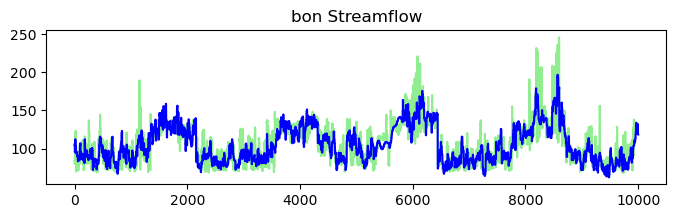

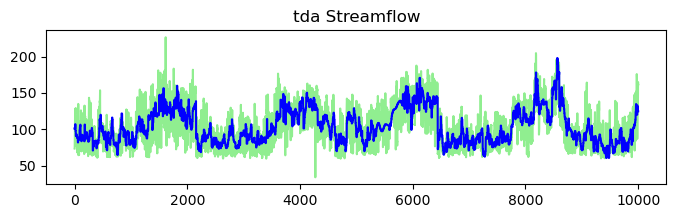

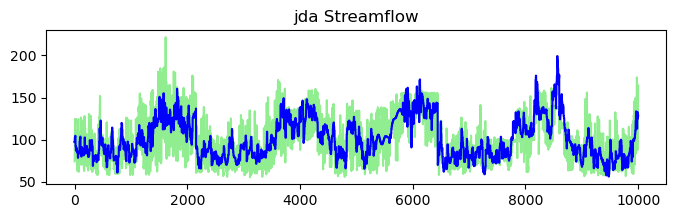

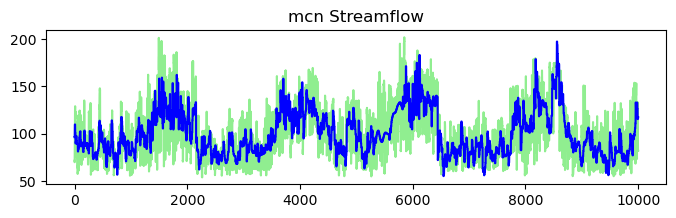

In [125]:
for u in units:
    T = 10000
    plt.figure(figsize=(8, 2))
    plt.plot(recon[f"{u}_inflow_avg"].iloc[0:T], label = "Reconstructed (1 hr)", color="lightgreen")
    plt.plot(compare[f"{u}_inflow"].iloc[0:T], label = "Ground Truth (6hr)", color="blue")
    # Ning reconstruct: Check indexing same time steps 
    # plt.plot(ref_subset[f"{u}_inflow"].iloc[0:T], label = "Ning Reconstructed")
    plt.title(f"{u} Streamflow")
    # plt.legend()
    plt.show()


In [111]:
# Calculate prediction error for EC rolling average
pred_error(compare, recon, units, "_inflow","_inflow_avg")


,unit,rmse,bias,corr
0,bon,14.490493,-1.691198e-15,0.819479
1,tda,21.047129,4.095871e-16,0.676763
2,jda,20.022646,2.483947e-15,0.701621
3,mcn,21.636856,3.910896e-15,0.656569


In [113]:
# Calculate prediction error for EC hourly inflow
pred_error(compare, recon, units, "_inflow","_inflow_recon_bc")


,unit,rmse,bias,corr
0,bon,14.490493,-1.691198e-15,0.819479
1,tda,21.047129,4.095871e-16,0.676763
2,jda,20.022646,2.483947e-15,0.701621
3,mcn,21.636856,3.910896e-15,0.656569


In [115]:
# Calculate prediction error for NQ hourly reconstructed
pred_error(compare, ref_subset, units, "_inflow","_inflow")

,unit,rmse,bias,corr
0,bon,98.010572,63.601338,0.155344
1,tda,87.307407,51.504225,0.155939
2,jda,97.197754,59.490811,0.157692
3,mcn,95.537740,60.793787,0.158446


# Estimate Travel Times

In [261]:
reaches = [
    ("mcn", "jda", 85), # miles between each unit 
    ("jda", "tda", 25),
    ("tda", "bon", 40),
]

vmin, vmax = 5, 20   # plausible river travel speed, miles/hour

q = recon.merge(outflow, on="datetime")
rows = []

for up, down, miles in reaches:
    lags = range(max(1, int(np.ceil(miles / vmax))),
                 int(np.floor(miles / vmin)) + 1)

    x = q[f"{up}_outflow"]
    y = q[f"{down}_inflow_avg"]

    corrs = [x.shift(h).corr(y) for h in lags]
    h = list(lags)[np.nanargmax(corrs)]

    rows.append({
        "reach": f"{up} → {down}",
        "miles": miles,
        "travel_time_hr": h,
        "speed_mph": miles / h,
        "corr": max(corrs),
    })

travel_time = pd.DataFrame(rows)
travel_time

,reach,miles,travel_time_hr,speed_mph,corr
0,mcn → jda,85,10,8.5,0.667360
1,jda → tda,25,2,12.5,0.757680
2,tda → bon,40,4,10.0,0.727893


# Inflow Forecasting

In [71]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [72]:
train_years = [2018, 2019, 2020, 2021, 2022]
test_years  = [2023, 2024, 2025]

In [73]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import r2_score
from statsmodels.graphics.tsaplots import plot_acf


def diagnose(result, unit, nlags=48):
    data = result[["actual", "predicted"]].dropna().sort_index()
    fitted = data["predicted"]
    residuals = data["actual"] - fitted

    print(f"{unit.upper()} test R²: "
          f"{r2_score(data['actual'], fitted):.3f}")

    fig, ax = plt.subplots(2, 2, figsize=(10, 7))

    ax[0, 0].scatter(fitted, residuals, s=8, alpha=0.4)
    ax[0, 0].axhline(0, color="black")
    ax[0, 0].set(
        title="Fitted vs residuals",
        xlabel="Predicted",
        ylabel="Residual",
    )

    ax[0, 1].hist(residuals, bins=40)
    ax[0, 1].set(
        title="Residual histogram",
        xlabel="Residual",
    )

    plot_acf(
        residuals,
        lags=min(nlags, len(residuals) - 1),
        ax=ax[1, 0],
    )

    sm.qqplot(residuals, line="s", ax=ax[1, 1])
    ax[1, 1].set_title("Normal Q-Q plot")

    fig.suptitle(unit.upper())
    plt.tight_layout()
    plt.show()

## Data Preprocessing

In [75]:
def add_season_year(df):
    df = df.copy()
    dt = pd.to_datetime(df["datetime"])
    df["season_year"] = dt.dt.year - (dt.dt.month <= 4)
    return df

In [284]:
# Feature map (not predicting mcnary since no upstream relesae)
reach_map = {
    "jda": ("jda_inflow_avg", "mcn_outflow", 24, [9, 10, 11]),
    "tda": ("tda_inflow_avg", "jda_outflow", 24, [1, 2, 3]),
    "bon": ("bon_inflow_avg", "tda_outflow", 24, [3, 4, 5]),
}

model_df = (
    recon[["datetime","bon_inflow_avg","tda_inflow_avg", "jda_inflow_avg",]]
    .merge(outflow[["datetime","tda_outflow","jda_outflow","mcn_outflow",]],on="datetime", how="inner",
    ).sort_values("datetime").reset_index(drop=True)
)

# Tag data year 
model_df = model_df.bfill()
model_df["datetime"] = pd.to_datetime(model_df["datetime"])
model_df = add_season_year(model_df)

In [286]:
model_df.head()

,datetime,bon_inflow_avg,tda_inflow_avg,jda_inflow_avg,tda_outflow,jda_outflow,mcn_outflow,season_year
0,2018-09-07 00:00:00,83.458768,73.443337,74.289808,67.8,73.5,67.8,2018
1,2018-09-07 01:00:00,83.458768,73.443337,74.289808,62.8,69.4,65.0,2018
2,2018-09-07 02:00:00,82.355889,73.643337,75.216074,63.0,69.9,63.8,2018
3,2018-09-07 03:00:00,79.750132,75.543337,76.289808,64.9,71.4,74.3,2018
4,2018-09-07 04:00:00,80.661647,83.243337,82.689808,72.6,77.8,83.9,2018


## Lagged Dataset

In [289]:
def make_lags(df, target, upstream, p, release_lags):
    d = df.copy()
    group = d.groupby("season_year")

    q_cols = [f"q_lag_{h}" for h in range(1, p + 1)]
    r_cols = [f"r_lag_{h}" for h in release_lags] # use predefined travel times 

    for h, col in zip(range(1, p + 1), q_cols):
        d[col] = group[target].shift(h)

    for h, col in zip(release_lags, r_cols):
        d[col] = group[upstream].shift(h)

    features = q_cols + r_cols 
    return d.dropna(subset=[target] + features), features

In [291]:
def fit_model(df, target, upstream, p, release_lags):
    lagged, features = make_lags(df, target, upstream, p, release_lags)
    train = lagged[lagged["season_year"].isin(train_years)]

    model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 40))
    )
    model.fit(train[features], train[target])

    return model, features

In [293]:
def summarize_fit(result):
    e = result["predicted"] - result["actual"]

    return {
        "RMSE": np.sqrt(np.mean(e**2)),
        "MAE": np.mean(np.abs(e)),
        "bias": e.mean(),
        "corr": result["actual"].corr(result["predicted"]),
    }

In [295]:
def one_step_predict(df, model, target, upstream,
                     test_years, p, release_lags):

    for h in range(1, p + 1):
        df[f"q_lag_{h}"] = (df.groupby("season_year")[target].shift(h))

    for h in release_lags:
        df[f"r_lag_{h}"] = (df.groupby("season_year")[upstream].shift(h))

    features = ([f"q_lag_{h}" for h in range(1, p + 1)] + [f"r_lag_{h}" for h in release_lags])

    test = df[df["season_year"].isin(test_years)].dropna(subset=features + [target])

    result = test[["datetime", "season_year"]].copy()
    result["actual"] = test[target]
    result["predicted"] = np.maximum(0, model.predict(test[features]))

    return result.set_index("datetime")

JDA test R²: 0.930


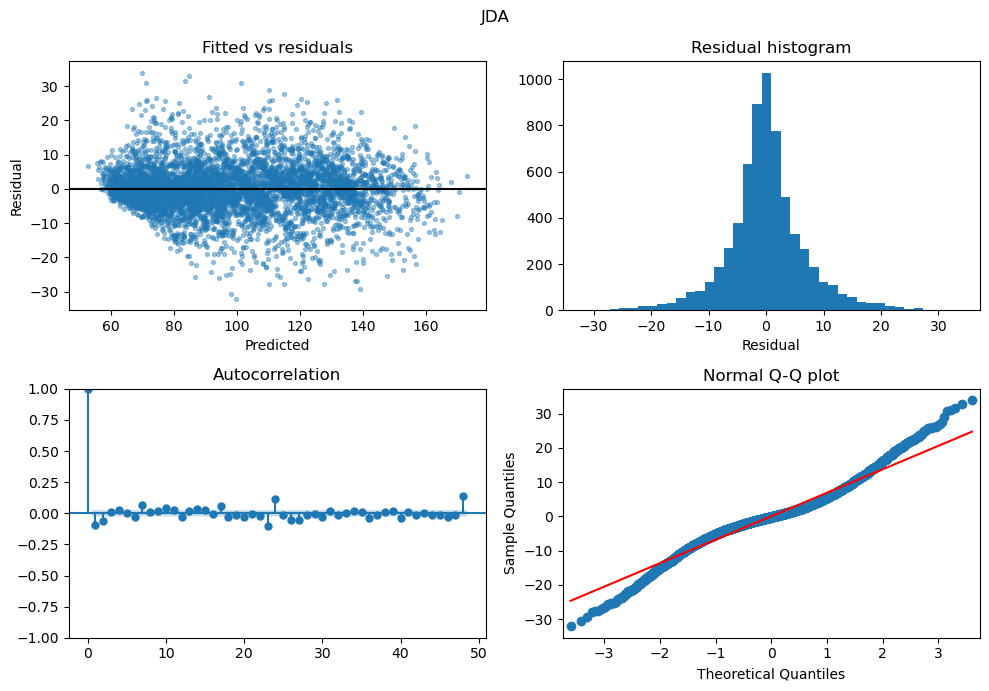

TDA test R²: 0.925


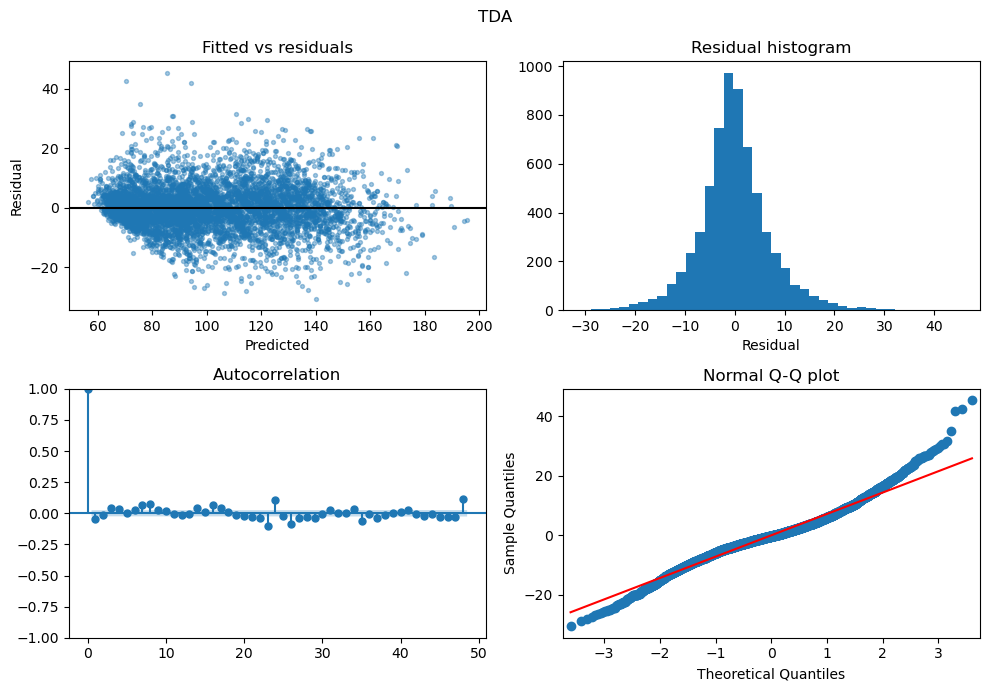

BON test R²: 0.971


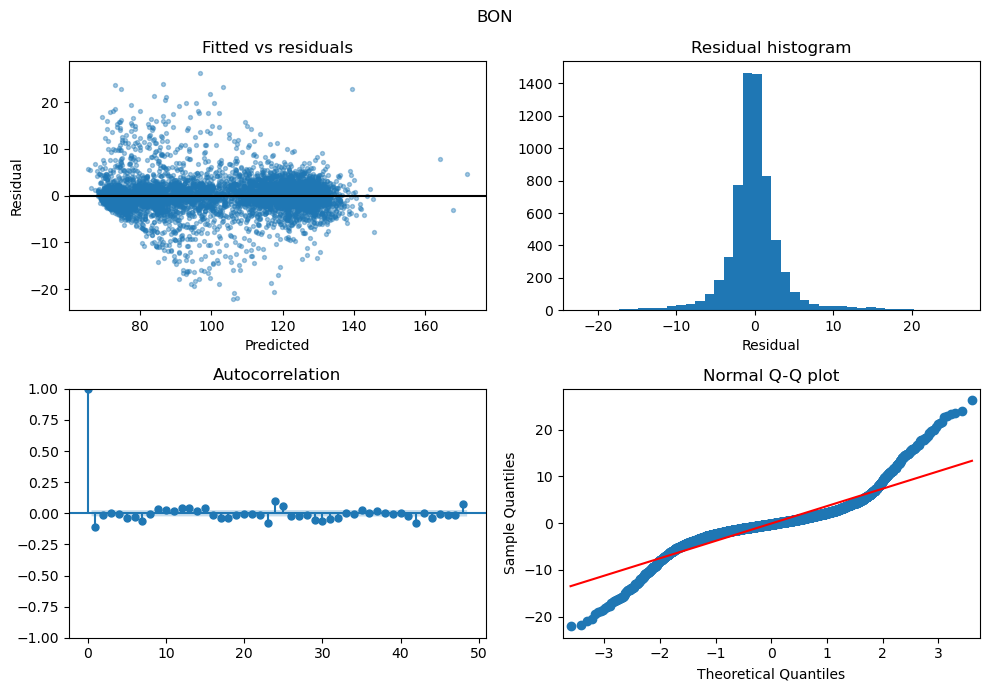

In [297]:
test_results = {}

for unit, (target, upstream, p, release_lags) in reach_map.items():

    # Fit regression using training data 
    model, features = fit_model(model_df, target, upstream, p, release_lags)

    # Test on training data, predicting one time step at a time 
    test_results[unit] = one_step_predict(model_df, model, target, upstream, test_years, p, release_lags)
    
for unit in ["jda", "tda", "bon"]:
    diagnose(test_results[unit], unit)

### Print Model Fit

In [299]:
# Print coeficients transformed back to real-world scale 
for unit, (target, upstream, p, release_lags) in reach_map.items():
    model, features = fit_model(model_df, target, upstream, p, release_lags)

    scaler = model[0]
    ridge = model[-1]

    coef = ridge.coef_ / scaler.scale_
    intercept = ridge.intercept_ - coef @ scaler.mean_

    print(f"\n{unit.upper()}")
    print(pd.Series(
        [intercept, *coef],
        index=["intercept", *features],
    ))


JDA
intercept    1.196582
q_lag_1      1.103326
q_lag_2     -0.249067
q_lag_3     -0.015380
q_lag_4      0.002325
q_lag_5      0.002080
q_lag_6     -0.037717
q_lag_7     -0.031418
q_lag_8     -0.005535
q_lag_9      0.038902
q_lag_10     0.021133
q_lag_11     0.016580
q_lag_12     0.019855
q_lag_13    -0.015722
q_lag_14    -0.013222
q_lag_15    -0.031248
q_lag_16    -0.028910
q_lag_17     0.008013
q_lag_18     0.036447
q_lag_19     0.010977
q_lag_20     0.025355
q_lag_21    -0.016201
q_lag_22     0.030009
q_lag_23     0.151888
q_lag_24    -0.060597
r_lag_9      0.043528
r_lag_10    -0.001397
r_lag_11    -0.013410
dtype: float64

TDA
intercept    1.611301
q_lag_1      1.076942
q_lag_2     -0.220175
q_lag_3     -0.040796
q_lag_4      0.005002
q_lag_5     -0.015331
q_lag_6     -0.043333
q_lag_7     -0.022490
q_lag_8     -0.009405
q_lag_9      0.066695
q_lag_10     0.015401
q_lag_11     0.026705
q_lag_12    -0.011869
q_lag_13    -0.003455
q_lag_14    -0.015966
q_lag_15     0.010390
q_lag_1

### Calculate Error Correlation Matrix

In [301]:
error_df = pd.concat(
    {
        unit: result["actual"] - result["predicted"]
        for unit, result in test_results.items()
    },
    axis=1
).dropna()

R = error_df.corr()
R

,jda,tda,bon
jda,1.000000,-0.033090,0.020604
tda,-0.033090,1.000000,0.014311
bon,0.020604,0.014311,1.000000


# Residual Modeling

In [90]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t
from statsmodels.graphics.tsaplots import plot_acf


AR_LAGS = [1]
PERSISTENCE_CAP = 0.995


# ============================================================
# 1. PREPARE ONE UNIT
# ============================================================

def prepare_data(unit, results):
    target, upstream, p, release_lags = reach_map[unit]
    travel_lag = release_lags[len(release_lags) // 2]

    d = (
        add_season_year(model_df)
        .sort_values("datetime")
        .copy()
    )

    d["ramp"] = (
        d.groupby("season_year")[upstream]
        .diff()
    )

    d["release"] = (
        d.groupby("season_year")[upstream]
        .shift(travel_lag)
    )

    d["ramp"] = (
        d.groupby("season_year")["ramp"]
        .shift(travel_lag)
        .abs()
    )

    d = d.set_index("datetime")

    d["residual"] = (
        results[unit]["actual"]
        - results[unit]["predicted"]
    )

    for lag in AR_LAGS:
        d[f"e_lag_{lag}"] = (
            d.groupby("season_year")["residual"]
            .shift(lag)
        )

    needed = (
        ["residual", "season_year", "release", "ramp"]
        + [f"e_lag_{lag}" for lag in AR_LAGS]
    )

    return d[needed].dropna()


# ============================================================
# 2. FIT AR + RELEASE/RAMP GARCH-X
# ============================================================

def fit_model(train):
    ar_features = [f"e_lag_{lag}" for lag in AR_LAGS]

    # Fit AR residual correction
    ar = LinearRegression().fit(
        train[ar_features],
        train["residual"],
    )

    innovation = (
        train["residual"]
        - ar.predict(train[ar_features])
    )

    innovation_mean = innovation.mean()
    innovation_scale = innovation.std()

    # Standardize innovations for numerical stability
    e = (
        (innovation - innovation_mean)
        / innovation_scale
    ).to_numpy()

    season = train["season_year"].to_numpy()
    reset = np.r_[True, season[1:] != season[:-1]]

    # Normalize release and ramp
    x_ranges = {}

    X = []

    for col in ["release", "ramp"]:
        xmin = train[col].min()
        xrange = train[col].max() - xmin
        xrange = xrange if xrange > 0 else 1

        X.append(
            (train[col].to_numpy() - xmin) / xrange
        )

        x_ranges[col] = (xmin, xrange)

    X = np.column_stack(X)

    def nll(par):
        omega, alpha, beta, gamma_u, gamma_r, nu = par
        sigma2 = np.empty(len(e))

        for i in range(len(e)):
            if reset[i]:
                sigma2[i] = 1
            else:
                sigma2[i] = (
                    omega
                    + alpha * e[i - 1]**2
                    + beta * sigma2[i - 1]
                    + gamma_u * X[i, 0]
                    + gamma_r * X[i, 1]
                )

            if not np.isfinite(sigma2[i]) or sigma2[i] <= 0:
                return 1e20

        loglik = (
            gammaln((nu + 1) / 2)
            - gammaln(nu / 2)
            - 0.5 * np.log(np.pi * (nu - 2))
            - 0.5 * np.log(sigma2)
            - (nu + 1) / 2
            * np.log1p(e**2 / ((nu - 2) * sigma2))
        )

        return -loglik[~reset].sum()

    starts = [
        [0.05, 0.05, 0.90, 0.05, 0.05, 8],
        [0.10, 0.15, 0.70, 0.10, 0.10, 5],
    ]

    bounds = [
        (1e-8, None),             # omega
        (0, PERSISTENCE_CAP),     # alpha
        (0, PERSISTENCE_CAP),     # beta
        (0, None),                # gamma release
        (0, None),                # gamma ramp
        (2.05, 100),              # nu
    ]

    constraint = {
        "type": "ineq",
        "fun": lambda p: (
            PERSISTENCE_CAP - p[1] - p[2]
        ),
    }

    fits = []

    for start in starts:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message=r"Values in x were outside bounds.*",
            )

            fit = minimize(
                nll,
                start,
                method="SLSQP",
                bounds=bounds,
                constraints=constraint,
                options={"maxiter": 5000, "ftol": 1e-8},
            )

        fits.append(fit)

    successful = [f for f in fits if f.success]
    fit = min(successful or fits, key=lambda f: f.fun)

    par = fit.x.copy()

    # Convert variance coefficients to original units
    par[0] *= innovation_scale**2
    par[3] *= innovation_scale**2
    par[4] *= innovation_scale**2

    return {
        "ar": ar,
        "garch": par,
        "innovation_mean": innovation_mean,
        "innovation_scale": innovation_scale,
        "x_ranges": x_ranges,
        "converged": fit.success,
        "train_innovation": innovation,
    }


# ============================================================
# 3. TEST FITTED MODEL
# ============================================================

def test_model(test, model):
    ar_features = [f"e_lag_{lag}" for lag in AR_LAGS]

    ar_prediction = model["ar"].predict(
        test[ar_features]
    )

    innovation = (
        test["residual"].to_numpy()
        - ar_prediction
        - model["innovation_mean"]
    )

    X = []

    for col in ["release", "ramp"]:
        xmin, xrange = model["x_ranges"][col]

        # Do not extrapolate below the training minimum
        x = np.maximum(
            0,
            (test[col].to_numpy() - xmin) / xrange,
        )

        X.append(x)

    X = np.column_stack(X)

    omega, alpha, beta, gamma_u, gamma_r, nu = (
        model["garch"]
    )

    season = test["season_year"].to_numpy()
    reset = np.r_[True, season[1:] != season[:-1]]
    sigma2 = np.empty(len(test))

    for i in range(len(test)):
        if reset[i]:
            sigma2[i] = model["innovation_scale"]**2
        else:
            sigma2[i] = (
                omega
                + alpha * innovation[i - 1]**2
                + beta * sigma2[i - 1]
                + gamma_u * X[i, 0]
                + gamma_r * X[i, 1]
            )

    z = innovation / np.sqrt(sigma2)

    loglik = (
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log(np.pi * (nu - 2))
        - 0.5 * np.log(sigma2)
        - (nu + 1) / 2
        * np.log1p(
            innovation**2 / ((nu - 2) * sigma2)
        )
    )

    output = test.copy()
    output["ar_prediction"] = ar_prediction
    output["innovation"] = innovation
    output["sigma"] = np.sqrt(sigma2)
    output["z"] = z
    output["reset"] = reset

    return output, -loglik[~reset].mean()


# ============================================================
# 4. FIT AND TEST ALL THREE UNITS
# ============================================================

models = {}
test_outputs = {}
rows = []

for unit in ["jda", "tda", "bon"]:
    train = prepare_data(unit, train_results)
    test = prepare_data(unit, test_results)

    model = fit_model(train)
    output, test_nll = test_model(test, model)

    models[unit] = model
    test_outputs[unit] = output

    ar = model["ar"]
    omega, alpha, beta, gamma_u, gamma_r, nu = (
        model["garch"]
    )

    valid = output.loc[~output["reset"]]
    z = valid["z"]

    row = {
        "unit": unit,
        "intercept": ar.intercept_,
        "phi_1": ar.coef_[0],
        "phi_2": ar.coef_[1],
        "phi_24": ar.coef_[2],
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "gamma_release": gamma_u,
        "gamma_ramp": gamma_r,
        "nu": nu,
        "persistence": alpha + beta,
        "test_NLL": test_nll,
        "converged": model["converged"],
    }

    for level in [0.90, 0.95, 0.99]:
        q = (
            t.ppf((1 + level) / 2, df=nu)
            * np.sqrt((nu - 2) / nu)
        )

        row[f"coverage_{int(level * 100)}"] = (
            np.abs(z) <= q
        ).mean()

    rows.append(row)


results_table = pd.DataFrame(rows)

display(results_table.round(4))

NameError: name 'train_results' is not defined

In [ ]:
# ============================================================
# 5. FINAL DIAGNOSTICS
# ============================================================

fig, ax = plt.subplots(3, 2, figsize=(10, 4))

for i, unit in enumerate(["jda", "tda", "bon"]):
    d = test_outputs[unit]
    z = d.loc[~d["reset"], "z"].dropna()

    plot_acf(
        z,
        lags=48,
        zero=False,
        ax=ax[i, 0],
    )

    ax[i, 0].set_title(
        f"{unit.upper()}: standardized innovations"
    )

    plot_acf(
        z**2,
        lags=48,
        zero=False,
        ax=ax[i, 1],
    )

    ax[i, 1].set_title(
        f"{unit.upper()}: squared innovations"
    )

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(11, 8))

for i, unit in enumerate(["jda", "tda", "bon"]):
    model = models[unit]
    d = test_outputs[unit].copy()

    # First two weeks of first test season
    first_season = d["season_year"].iloc[0]

    d = d[
        d["season_year"] == first_season
    ].iloc[:24 * 14]

    nu = model["garch"][-1]

    q95 = (
        t.ppf(0.975, df=nu)
        * np.sqrt((nu - 2) / nu)
    )

    # Time-varying DDU and constant DIU intervals
    ddu_bound = q95 * d["sigma"]
    diu_bound = q95 * model["innovation_scale"]

    ax[i].plot(
        d.index,
        d["innovation"],
        color="black",
        linewidth=0.7,
        label="Forecast innovation",
    )

    ax[i].fill_between(
        d.index,
        -ddu_bound,
        ddu_bound,
        color="tab:red",
        alpha=0.25,
        label="DDU 95% interval",
    )

    ax[i].plot(
        d.index,
        np.full(len(d), diu_bound),
        "--",
        color="tab:blue",
        linewidth=1,
        label="DIU 95% interval",
    )

    ax[i].plot(
        d.index,
        np.full(len(d), -diu_bound),
        "--",
        color="tab:blue",
        linewidth=1,
    )

    ax[i].axhline(0, color="gray", linewidth=0.5)
    ax[i].set_title(unit.upper())
    ax[i].set_ylabel("Forecast error")

ax[0].legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

for i, unit in enumerate(["jda", "tda", "bon"]):
    model = models[unit]
    d = test_outputs[unit]

    omega, alpha, beta, gamma_u, gamma_r, nu = (
        model["garch"]
    )

    release_min, release_range = (
        model["x_ranges"]["release"]
    )

    ramp_min, ramp_range = (
        model["x_ranges"]["ramp"]
    )

    release = np.linspace(
        release_min,
        release_min + release_range,
        60,
    )

    ramp = np.linspace(
        ramp_min,
        ramp_min + ramp_range,
        60,
    )

    release_grid, ramp_grid = np.meshgrid(
        release,
        ramp,
    )

    release_scaled = (
        release_grid - release_min
    ) / release_range

    ramp_scaled = (
        ramp_grid - ramp_min
    ) / ramp_range

    # Hold previous innovation and variance at typical values
    error2_reference = (
        d["innovation"]**2
    ).median()

    variance_reference = (
        d["sigma"]**2
    ).median()

    sigma = np.sqrt(
        omega
        + alpha * error2_reference
        + beta * variance_reference
        + gamma_u * release_scaled
        + gamma_r * ramp_scaled
    )

    contour = ax[i].contourf(
        release_grid,
        ramp_grid,
        sigma,
        levels=15,
        cmap="Reds",
    )

    fig.colorbar(
        contour,
        ax=ax[i],
        label="Conditional standard deviation",
    )

    ax[i].set(
        title=unit.upper(),
        xlabel="Upstream release",
        ylabel="Absolute upstream ramp",
    )

plt.tight_layout()
plt.show()

In [ ]:
train_outputs = {}

for unit in ["jda", "tda", "bon"]:
    train = prepare_data(unit, train_results)

    train_outputs[unit], _ = test_model(
        train,
        models[unit],
    )

z_df = pd.concat(
    {
        unit: output.loc[~output["reset"], "z"]
        for unit, output in train_outputs.items()
    },
    axis=1,
).dropna()

R = z_df.corr()
R

In [ ]:
# D_t = np.diag(sigma_t)
# Sigma_t = D_t @ R.to_numpy() @ D_t